# Group assignment 2.1: simulation of transport of pollutant in rivers

*Due: Friday, November 14th 2025. 12:30*

# Introduction

The objective of GA 2.1 is to obtain insight into the time integration and space discretization of the advection-diffusion
equation and to learn about the resulting numerical errors and artefacts.
In this respect, accuracy and stability play a major role.

In this assignment we are dealing with a cloud of pollutant that is propagating and spreading throughout a river.
(See also the Workshop Assignment of last Wednesday.)
We consider a river section in which one finds a given cloud of pollutant at $t = 0$. Initially, the cloud of pollutant has a block-shaped
profile with a concentration of 1 kg/m<sup>3</sup>.
Further details on this test case are given below.

You are provided with the Python script containing the code for the solution of the 1D advection-diffusion equation (see one of the cells below.)

Several runs must be made with the Python script. These runs will be carried out to
- examine the accuracy of time integration - **part I**
- investigate the impact of numerical diffusion - **part II**
- explore the stability of various schemes - **part III**

# Part I

We start first with a bit of theory on time integration.

## Time integration using the $\theta$-method

During the course you were introduced to the following two time integration methods, namely
- the forward Euler scheme and
- the backward Euler scheme.

Each of these methods has its advantages and disadvantages. Basically, the forward Euler is conditionally stable
while the backward Euler is unconditionally stable. On the other hand, the former is simple to implement and also
cheap in terms of function evaluations while the latter usually results into a system of equations that need
to be solved.
Both methods, however, are first order accurate in time, which could potentially be a disadvantage in many applications.
Now let us take a look at how we can improve this.

Consider the following first order ODE

$$
  \frac{dy}{dt} = f(y)
$$

where we seek for a solution $y(t)$ in the range $0 \leq t \leq T_{\text{end}}$.
This time frame is discretized into a number of steps with a step size of $\Delta t$:
$\{t_n = n\Delta t \,\,|\,\, n = 0, 1, 2, \cdots\}$.
Then, the forward (explicit) Euler scheme is given by

$$
  \frac{y^{n+1}-y^n}{\Delta t} = f(y^n)
$$

while the backward (implicit) Euler scheme reads

$$
  \frac{y^{n+1}-y^n}{\Delta t} = f(y^{n+1})
$$

Again, both schemes have a truncation error of $\tau_{\Delta t} = \mathcal{O}(\Delta t)$.

If we take the average of the forward and backward Euler schemes, we get

$$
  \frac{y^{n+1}-y^n}{\Delta t} = \frac 12 f(y^n) + \frac 12 f(y^{n+1})
$$

which is known as the **Crank-Nicolson scheme** or the **trapezoidal rule** (see also Chapter *Numerical Modelling* of the MUDE book).
Since the last term of the right-hand side needs to be evaluated based on the solution at the next time step $y^{n+1}$,
the Crank-Nicolson scheme is regarded as *implicit*. Like the backward Euler, this scheme has the disadvantage of the required
system of equations to be solved, but has the advantageous property of unconditional stability.

The reason behind averaging the forward and backward Euler schemes is to improve the accuracy of the resulting scheme.
Indeed, the truncation error of the Crank-Nicolson scheme is given as $\tau_{\Delta t} = \mathcal{O}(\Delta t^2)$.


<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 1.1</b>

This is a pen-and-paper exercise.
To test the accuracy of the Crank-Nicolson scheme we consider the following linear **test equation**

$$
  \frac{dy}{dt} = \lambda\, y
$$

with $\lambda < 0$ an arbitrary constant.

Verify that the truncation error of the Crank-Nicolson scheme is of second order using the Taylor series expansions.

</p>
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>

$\text{Hint:}$

Make full use of the test equation and its derivatives.

</p>
</div>

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
<b>Solution 1.1</b>

First, we replace the numerical solution $y^n$ by the exact one, that is, $y(t_n)$. Hence, we consider the following equation for
the error analysis

$$
  \frac{y(t_{n+1})-y(t_n)}{\Delta t} = \frac 12 \lambda \left ( y(t_n) + y(t_{n+1}) \right ) + \tau_{\Delta t}
$$

with $\tau_{\Delta t}$ the truncation error.

Next, we expand the function $y(t_{n+1})$ using Taylor series till order 3, as follows

$$
  y(t_{n+1}) = y(t_n) + \Delta t\,y_t(t_n) + \frac 12 \Delta t^2\,y_{tt}(t_n) + \frac 16 \Delta t^3\,y_{ttt}(t_n)
$$

with $y_t$, $y_{tt}$ and $y_{ttt}$ the first, second and third derivatives of $y$ to $t$, respectively.
Note that we have truncated the Taylor series after third order since we expect second order accuracy approximation for the first
derivative (2+1=3).

By substitution we obtain the following expression of the truncation error

$$
\begin{align*}
  \tau_{\Delta t} &= \frac{y(t_{n+1})-y(t_n)}{\Delta t} - \frac 12 \lambda \left ( y(t_n) + y(t_{n+1}) \right ) \\
                  \\
                  &= y_t + \frac 12 \Delta t\,y_{tt} + \frac 16 \Delta t^2\,y_{ttt} -
                  \lambda \left ( y + \frac12 \Delta t\,y_t + \frac 14 \Delta t^2\,y_{tt} + \frac{1}{12} \Delta t^3\,y_{ttt} \right )
                  + \mathcal{O}(\Delta t^4) \\
                  \\
                  &= \left ( {\color{red} y_t - \lambda y} \right ) + \frac 12 \Delta t \left ( {\color{green} y_{tt} - \lambda y_t} \right ) +
                     \Delta t^2 \left ( \frac 16 y_{ttt} - \frac 14 \lambda y_{tt} \right ) + \mathcal{O}(\Delta t^3) \\
                  \\
                  &= \Delta t^2 \left ( \frac 16 y_{ttt} - \frac 14 \lambda y_{tt} \right ) + \mathcal{O}(\Delta t^3) \\
                  \\
                  &= \mathcal{O}(\Delta t^2)
\end{align*}
$$

Note that we have used the following expressions here:

$$
  {\color{red} y_t = \lambda \, y} \quad \Rightarrow \quad {\color{green} y_{tt} = \lambda \, y_t}
$$

so that the first two colored terms can be cancelled.

</p>
</div>

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 1.2</b>

Reconsider the test equation

$$
  \frac{dy}{dt} = \lambda\, y
$$

Why should the parameter $\lambda$ be negative?

</p>
</div>

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
<b>Solution 1.2</b>

The solution of the test equation is given by

$$
  y(t) = y_0\,e^{\lambda t}
$$

where $y_0$ is the integration constant that can be determined by an initial condition.

Clearly, when $\lambda > 0$ the solution is continuously increasing in such a way that $y(t) \rightarrow \infty$, if $t \rightarrow \infty$.
This implies that the test equation with $\lambda > 0$ is an ill-posed problem. (Its solution is not bounded.)

On the other hand, if $\lambda < 0$, then $y(t) \rightarrow 0$ for $t \rightarrow \infty$, so that the solution remains stable.
Therefore, we required for the above test equation that $\lambda < 0$.

</p>
</div>

All the three mentioned schemes above can be generalized to an arbitrary weighted average of $f(y^n)$ and $f(y^{n+1})$, as follows

$$
  \frac{y^{n+1}-y^n}{\Delta t} = \theta\, f(y^{n+1}) + \left ( 1 - \theta \right ) \,f(y^n) 
$$

with $0 \leq \theta \leq 1$ a weight parameter to be chosen. This scheme is called the $\theta$-method
and is explicit if $\theta = 0$ and implicit if $0 < \theta \leq 1$. The parameter $\theta$ is called the
**implicitness parameter**. In practice, we will be almost exclusively interested in either
- forward Euler ($\theta = 0$) or
- backward Euler ($\theta = 1$) or
- Crank-Nicolson ($\theta = 1/2$)

In the remainder of this assignment we will work with these three schemes.

## Python script for numerical solution to advection-diffusion equation

Here we outline the usage of the Python script below that solves the following advection-diffusion equation in 1D:

$$
  \frac{\partial c}{\partial t} + v \frac{\partial c}{\partial x} - K\frac{\partial^2 c}{\partial x^2} = 0\, , \quad x \in [0,L]
$$

where $c(x,t)$ is the concentration of pollutant, $v$ is the constant flow velocity, $K$ is the constant diffusion coefficient
and $L$ is the length of the river section. The parameters $v$, $K$ and $L$ need to be specified by the user.

An initial condition $c(x,0) = c0(x)$ must be provided by the user such that $c0(0) = c0(L) = 0$, so that no boundary conditions need to be imposed.

**The code in the cell below is complete and does not need to be modified.** The use of function `advdiff` is as follows:

```
c = advdiff ( v, K, c0, L, dt, T, dxmethod, dtmethod, theta )
```

and the input parameters are defined as follows:
- `v` = flow velocity (in m/s)
- `K` = diffusion coefficient (in m<sup>2</sup>/s)
- `c0` = initial condition (row vector)
- `L` = length of domain (in m)
- `dt` = time step (in s)
- `T` = simulation end time (in s)
- `dxmethod` = spatial discretization scheme
- `dtmethod` = time integration scheme
- `theta` = implicitness parameter ($0 \leq $ `theta` $\leq 1$)

The output parameter is `c` which contains the numerical solution of the advection-diffusion equation.
This variable is a 2D array `c[0:N,0:M]` with `N` the number of time steps and `M` the number of grid cells.
The grid is equidistant so that the grid points are uniformly distributed with a constant grid size $\Delta x = L/$`M`.

The row vector `c0` represents the initial value of $c(x,0)$ at uniformly spaced points in $[0,L]$.
Hence, the dimension of this vector is `c0[0:M]`.
Note that `c0` is a grid function and thus indirectly defines the computational grid.

The allowed values of `dxmethod` in this assignment are:
- `central` = second order central differences
- `upwind` = first order upwind scheme

These two methods only concern the advection term while the diffusion term is approximated exclusively with central differences.

The relevant value of `dtmethod` in this assignment is `'theta'` and represents the $\theta$-method as discussed in the
previous section.

The last argument of `advdiff` specifies the actual value of the implicitness parameter $\theta$. Special cases are
- `theta = 0.0` is forward Euler
- `theta = 0.5` is Crank-Nicolson
- `theta = 1.0` is backward Euler

Now run the cell below.

In [1]:
# You do not need to change anything in this cell

import warnings
import numpy as np

def advdiff(v = None,K = None,c0 = None,L = None,dt = None,T = None,dxmethod = None,dtmethod = None,theta = None):

    # advdiff - solve the advection-diffusion equation in one dimension on
    #           the interval [0,L]. The advection-diffusion equation is
    #           given by:
     
    #                      2
    #      dc     dc      d c
    #      -- + v --  - K --- = 0
    #      dt     dx        2
    #                     dx
     
    #    An initial condition c(x,0)= c0(x) must be given such that
    #    c0(0) = c0(L) = 0, so that no boundary conditions need to be imposed
     
    #    Input parameters
    #    ----------------
     
    #    c=advdiff(v, K, c0, L, dt, T, dxmethod, dtmethod, theta)
     
    #    v        - velocity
    #    K        - diffusion coefficient
    #    c0       - row vector of initial condition
    #    L        - the length of the domain
    #    dt       - time step
    #    T        - simulation end time
    #    dxmethod - name of spatial discretization
    #    dtmethod - name of time integration
    #    theta    - implicitness parameter
     
    #    Output parameter
    #    ----------------
     
    #    The output parameter is c which is the numerical solution of the
    #    advection-diffusion equation. The parameter c is a two-dimensional
    #    array c[0:N,0:M] with N the number of time steps and M the number
    #    of grid cells. So, the number of grid points is therefore M + 1
    #    (including the boundary points).
     
    #    Initial condition
    #    -----------------
     
    #    The row vector c0 represents the initial value of c at uniformly
    #    spaced points in [0,L]. Hence, the dimension of c0 is c0[0:M].
     
    #    Spatial discretization
    #    ----------------------
     
    #    The allowed values of dxmethod are:
     
    #    'central' - second order central differences
    #
    #    'upwind'  - first order upwind scheme
    #
    #    'bdf'     - second order BDF scheme
    #
    #    'quick'   - second order QUICK scheme
    #
    #    'box'     - spatial component of the box scheme
    #                note: you also need to use the 'box' method for time integration
     
    #    Time integration
    #    ----------------
     
    #    The allowed values of dtmethod are:
    #
    #    'theta'        - theta-method
    #                     special cases:
    #                       theta=0.0 is explicit Euler
    #                       theta=0.5 is Crank-Nicolson
    #                       theta=1.0 is implicit Euler
    #
    #    'box'          - theta-box scheme
    #                     the value of theta is 0.5 to 1
    #                     the Preissmann scheme is a special case with theta=0.5
    #
    #    'leapfrog'     - Leapfrog scheme
    #                     note: parameter theta is not used
    #
    #    'Lax-Wendroff' - Lax-Wendroff scheme
    #                     note: parameter theta is not used
    #
    #    'Beam-Warming' - Beam-Warming scheme
    #                     note: parameter theta is not used
    #
    #   Note that the diffusion term is only supported by central differences
    #   combined with the theta-method

    # set K to zero for BDF, QUICK and BOX schemes, or Leapfrog, Lax-Wendroff and Beam-Warming time stepping methods 
    if (dxmethod != 'central' and dxmethod != 'upwind') or dtmethod != 'theta':
       if K != 0.:
          K = 0.
          warnings.warn('Diffusion coefficient has been set to zero')

    # set number of time steps 
    timesteps = int(T/dt)+1

    # initialize solution matrix (c[n,:] is the solution at timestep n)
    c = np.zeros((timesteps,len(c0)))

    # copy the initial condition into the first row of the solution matrix
    c[0,:] = c0
    
    # if Leapfrog then also write it to the second row
    if dtmethod == 'leapfrog': c[1,:] = c0
    
    # number of grid points
    points = len(c[0])

    # spatial grid size
    dx = L / (points - 1)

    #------------------------------------------------------------------------
    # Generate the spatial discretization template
    #------------------------------------------------------------------------
    
    # Calculate the templates for the first and second derivatives
    dcdx1 = dcdx(dx,1,v,dxmethod)
    dcdx2 = dcdx(dx,2,v,dxmethod)

    # dc/dt = -v(dc/dx) + K(d^2c/dx^2)
    template = - v * dcdx1 + K * dcdx2

    # Special case for Lax-Wendroff and Beam-Warming since these schemes produce artificial diffusion
    if dtmethod == 'Lax-Wendroff' or dtmethod == 'Beam-Warming':
       template = - v * dcdx1 + 0.5 * dt * v**2 * dcdx2
    
    # For a larger stencil, like BDF and QUICK, also a lower stencil of upwind to be applied to boundaries
    dcdx1 = dcdx(dx,1,v,'upwind')
    dcdx2 = dcdx(dx,2,v,'upwind')
    if dxmethod == 'bdf' or dxmethod == 'quick':
       templateb = - v * dcdx1 + K * dcdx2
    else:
       templateb = template

    #------------------------------------------------------------------------
    # Generate the matrix of the semi-discretized system:
    #
    #   dc
    #   -- = Ain*c
    #   dt
    #
    #------------------------------------------------------------------------
    
    # discretization matrix
    Ain = np.zeros((points,points))

    # l is the extent of the template on each side of the diagonal (for example if template= [0, a, b ,c, 0] then l=1)
    l = int((len(template)-1)/2)

    # interior points
    for i in range(l,points-l):
        Ain[i,i-l:i+l+1] = template
   
    # left boundary (note that we leave the first line blank since c0[0] is constant)   
    for i in range(1,l-1):
        # boundary template entries in the matrix
        Ain[i,0:i+l] = templateb[l-i+1:2*l+1]
        # template entries over the edge of the matrix
        for j in range(0,l-i+1):
            Ain[i,0] = Ain[i,0] + templateb[j]
    
    # right boundary    
    for i in range(points-l+1,points):
        # boundary template entries in the matrix
        Ain[i,i-2:points] = templateb[0:2+points-i]
        # template entries over the edge of the matrix
        for j in range(2+points-i,3):
            Ain[i,points-1] = Ain[i,points-1:] + templateb[j]

    #------------------------------------------------------------------------
    # Run the simulation
    #------------------------------------------------------------------------
    
    # the loop starts after the initial conditions
    if dtmethod == 'leapfrog':
        for i in range(1,timesteps-1):
            # set up the stiffness matrix and load vectors for the ith and (i-1)th timesteps
            A,b = dcdt(dt,Ain,c[i,:],c[i-1,:],dtmethod,theta)
            # solve A c(i+1) = b for c(i+1)
            c[i+1,:] = np.linalg.solve(A,b)
    else:
        for i in range(0,timesteps-1):
            # set up the stiffness matrix and load vector for the ith timestep
            A,b = dcdt(dt,Ain,c[i,:],c[i,:],dtmethod,theta)
            # solve A c(i+1) = b for c(i+1)
            c[i+1,:] = np.linalg.solve(A,b)

    return c

#------------------------------------------------------------------------
# Time integration
#------------------------------------------------------------------------
    
def dcdt(dt = None,Ain = None,cn = None,cnn = None,method = None,theta = None): 
    # Given a spatial discretization Ain, solution vectors cn and cnn, and
    # time step dt, conduct the time integration according to method
    
    n = len(Ain)

    if method == 'theta':
       # theta method: c(n+1)/dt-c(n)/dt=theta*Ain*c(n+1) + (1-theta)*Ain*c(n)
       A = np.eye(n) - dt * theta * Ain
       b = (np.eye(n) + dt * (1. - theta) * Ain).dot(cn)
    else:
       if method == 'leapfrog':
          # Leapfrog is a two-step scheme
          A = np.eye(n)
          b = cnn + 2 * dt * Ain.dot(cn)
       else:
          if method == 'Lax-Wendroff':
             # Lax-Wendroff scheme is an explicit scheme
             A = np.eye(n)
             b = (np.eye(n) + dt * Ain).dot(cn)
          else:
             if method == 'Beam-Warming':
                # Beam-Warming scheme is an explicit scheme
                A = np.eye(n)
                b = (np.eye(n) + dt * Ain).dot(cn)
             else:
                if method == 'box':
                   # theta-box method: 0.5*(c(n+1)_j+c(n+1)_(j+1)-c(n)_j-c(n)_(j+1))/dt = theta*Ain*c(n+1) + (1-theta)*Ain*c(n)
                   v = np.ones(n-1)
                   A =  0.5 * (np.eye(n) + np.diag(v,-1)) - dt * theta * Ain
                   b = (0.5 * (np.eye(n) + np.diag(v,-1)) + dt * (1. - theta) * Ain).dot(cn)
                else:
                   raise Exception(np.array(['Unknown time integration method: ',method]))

    return A,b

 #------------------------------------------------------------------------
 # Spatial discretization
 #------------------------------------------------------------------------
    
def dcdx(dx = None,n = None,v = None,method = None): 
    # Return a vector containing the interior stencil for the nth spatial derivative according to method
    # dx is the mesh width
    
    # Notes:
    #   the stencils for a method must be of odd length and centred on the main diagonal
    #   the stencils for the first and second derivative must be the same size
    
    if method == 'central':
        # second order central differences
        if n == 1:
           dc = np.array([-1./(2.*dx), 0., 1./(2.*dx)])
        else:
           dc = np.array([1./(dx**2), -2./(dx**2), 1./(dx**2)])
    else:
        if method == 'box':
           # box scheme (note that only the first derivative is supported)
           if n == 1:
              dc = np.array([-1./dx, 1./dx, 0.])
           else:
              dc = np.array([0.,0.,0.])
        else:
           if method == 'upwind':
              # first order upwind scheme
              if n == 1:
                 if v > 0:
                    dc = np.array([-1./dx, 1./dx, 0.])
                 else:
                    dc = np.array([0., -1./dx, 1./dx])
              else:
                 dc = np.array([1./(dx**2), - 2./(dx**2), 1./(dx**2)])
           else:
              if method == 'bdf':
                 # second order BDF scheme
                 if n == 1:
                    if v > 0:
                       dc = np.array([1./(2.*dx), - 4./(2.*dx), 3./(2.*dx), 0., 0.])
                    else:
                       dc = np.array([0., 0., -3./(2,*dx), 4./(2,*dx), -1./(2,*dx)])
                 else:
                    if v > 0:
                       dc = np.array([1./(dx**2), -2./(dx**2), 1./(dx**2), 0., 0.])
                    else:
                       dc = np.array([0., 0., 1./(dx**2), -2./(dx**2), 1./(dx**2)])
              else:
                 if method == 'quick':
                    # second order QUICK scheme (note that only the first derivative is supported)
                    if n == 1:
                       if v > 0:
                          dc = np.array([1./(8.*dx), -7./(8.*dx), 3./(8.*dx), 3./(8.*dx), 0.])
                       else:
                          dc = np.array([0., -3./(8.*dx), -3./(8.*dx), 7./(8.*dx), -1./(8.*dx)])
                    else:
                       dc = np.array([0.,0.,0.,0.,0.])
                 else:
                    raise Exception(np.array(['Unknown spatial discretization scheme: ',method]))

    return dc

## Example

Here we give an example. Let us first define the domain by choosing a length of 60 km.
Furthermore, we place a uniform grid on this domain with a grid size of 100 m.

Next, we specify the initial condition `c0`. For example, we want to initialize a *block-shaped* profile with a width of 4 km.

Make sure that you understand the code below and run the cell below to plot the specified initial condition.

Text(0, 0.5, 'concentration [kg/m3]')

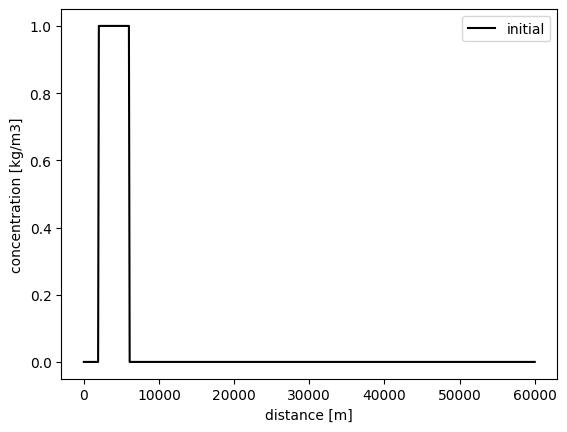

In [2]:
import numpy as np
import matplotlib.pyplot as plt

lenD = 60000.             # domain length
lenC = 4000.              # width of c0

dx = 100.                 # grid size
M = int(lenD/dx) + 1      # number of grid points
x = np.linspace(0,lenD,M) # array with coordinates of grid points

# initial condition
c0 = np.zeros(M)
c0[int(0.5 * lenC/dx):int(0.5 * lenC/dx) + int(lenC/dx) + 1] = 1.
plt.plot(x,c0,'k',label='initial')
plt.legend(loc='upper right')
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')

Now we want to solve the PDE with $v = 0.3$ m/s and $K = 0$ m<sup>2</sup>/s. (Note: we actually solves the advection equation.)
For this, we choose the **FTBS scheme** where the spatial derivative is approximated using the first order upwind scheme
(*backward in space*) while integrated over time using the forward Euler scheme (*forward in time*).

Furthermore, we set the time step to $\Delta t = 100$ s and simulation time $T_{\text{end}}$ to 140000 s.
Hence, there are 1400 time steps in total and the CFL number equals

$$
  \sigma = \frac{v\,\Delta t}{\Delta x} = \frac{0.3 \times 100}{100} = 0.3
$$

implying that FTBS will generate a *stable* solution. This solution can be obtained with the following command

In [3]:
# parameters for advdiff
v=0.3
K=0.0
dt=100.0
Tend=140000.0
scheme='upwind'
teta=0.0
#
# compute solution to PDE
c=advdiff(v,K,c0,lenD,dt,Tend,scheme,'theta',teta)

Finally, we want to plot the solution at the *final* time step, as follows

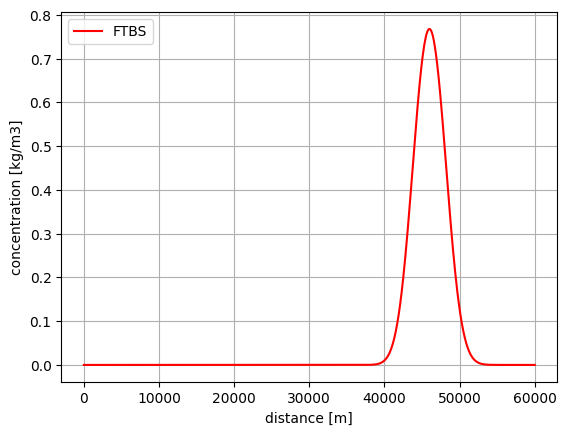

In [4]:
plt.plot(x,c[1400,:],'r',label='FTBS')
plt.legend(loc='upper left')
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.grid()

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 1.3</b>

For this task we set `v` = 0.5 m/s and `K` = 30 m<sup>2</sup>/s.
Use the other relevant parameters from the example above.
Make sure that the grid size equals 100 m.
Also make sure that the solution at *final time step* does not leave the domain (see Task 1.1 of WS 2.1).

Make a calculation using the function `advdiff` with the trapezoidal rule. Choose central differences for the spatial discretization.
Start with a relatively large time step and then decrease the time step until the results of two different time steps yield *visually*
identical answers. Make a graph that shows these two curves and include the time step for which this happens in your report.

</p>
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>

$\text{Tip:}$

Use the [Courant number](https://mude.citg.tudelft.nl/book/2025/numerical_methods_for_PDEs/advection_equation.html#the-upwind-method) to determine a time step instead of choosing that time step directly.

</p>
</div>

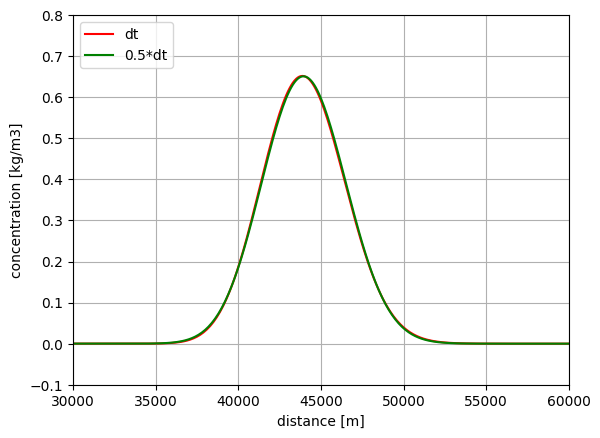

In [5]:
# parameters for Task 1.3

v = 0.5
K = 30.

distance = lenD - 20000.
Tend = np.ceil(distance/v)

dxmethod = 'central'
dtmethod = 'theta'

# trapezoidal rule
theta = 0.5

# start with sigma = 10, end with 2.5
sigma = 2.5

# compute the time step
dt = sigma * dx / v

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# get solution of the final time step
N = int(Tend/dt)

# plot the result
plt.plot(x,c[N,:],'r',label='dt')

# reduce time step by factor 2
sigma = sigma / 2

# compute the time step
dt = sigma * dx / v

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# get solution of the final time step
N = int(Tend/dt)

# plot the result
plt.plot(x,c[N,:],'g',label='0.5*dt')

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.1,0.8]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 1.4</b>

We repeat the calculations of **Task 1.3**, but with the forward Euler scheme. Since this scheme is conditionally stable, we cannot start
with an arbitrary large time step. Therefore, we set the maximum Courant number to $\sigma = 5/6$. (Again, $\Delta x = 100$ m.)
So start with the largest possible time step and then decrease it subsequently until the numerical results remain unchanged.

Include your graph and the observed time step in your report.

Compare your result with that of the trapezoidal rule. Explain your findings based on the notion of *order of accuracy*. Note: write down
your findings and conclusions in your report.

</p>
</div>

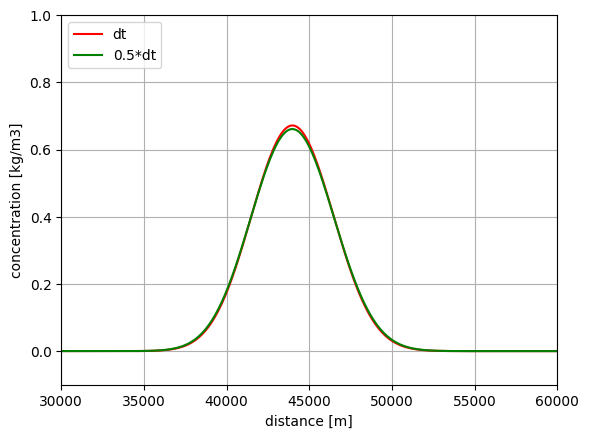

In [6]:
# parameters for Task 1.4

# forward Euler
theta = 0.0

# start with sigma = 5/6 (stable), end with 0.1
sigma = 0.1

# compute the time step
dt = sigma * dx / v

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# get solution of the final time step
N = int(Tend/dt)

# plot the result
plt.plot(x,c[N,:],'r',label='dt')

# reduce time step by factor 2
sigma = sigma / 2

# compute the time step
dt = sigma * dx / v

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# get solution of the final time step
N = int(Tend/dt)

# plot the result
plt.plot(x,c[N,:],'g',label='0.5*dt')

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.1,1.0]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

# Part II

In this part of the assignment we will investigate the impact of numerical diffusion.
In general, there are two contributions to this numerical diffusion:
- the first order upwind scheme
- the $\theta$-method

To ensure that only numerical diffusion is at play, we set $K = 0$, so that there is no physical diffusion.
The other parameters of the previous runs in part I remain unchanged.

Since $K=0$, we solves the advection equation

$$
  \frac{\partial c}{\partial t} + v\,\frac{\partial c}{\partial x} = 0
$$

which represents the propagation of the substance in the river while the block shape remains unchanged throughout the journey.
In this way we can use this exact propagated solution for comparison with the obtained numerical solutions.

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 2.1</b>

Use function `advdiff` to do the following four runs:
- first order upwind and $\theta = 0$
- central differences and $\theta = 0.5$
- central differences and $\theta = 0.7$
- central differences and $\theta = 1.0$

For these runs, set $\Delta x = 100$ m and $\sigma = 0.75$.

Include a graph containing the results of the four runs together with the analytical solution. Clearly mark which curve belongs to which run.

Answer the following questions in your report.
1. Which of the schemes has the most numerical diffusion?
2. For what value of $\theta$ is the numerical diffusion the largest?
3. For what value of $\theta$ is there no numerical diffusion?
4. Which of the two contributions to numerical diffusion has the largest impact?
   - the first order upwind scheme or
   - the $\theta$-method
5. Which of the schemes gives a non-negative solution?

</p>
</div>

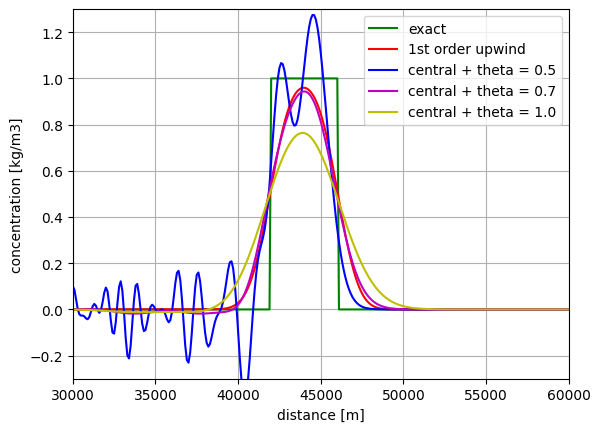

In [7]:
# parameters for Task 2.1

K = 0.

# true solution propagated
c1 = np.zeros(M)
c1[int(0.5 * lenC/dx + distance/dx):int(0.5 * lenC/dx + distance/dx) + int(lenC/dx) + 1] = 1.
plt.plot(x,c1,'g',label='exact')

dxmethod = 'upwind'
theta = 0.0
sigma = 0.75

# compute the time step
dt = sigma * dx / v

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# get solution of the final time step
N = int(Tend/dt)

# plot the result
plt.plot(x,c[N,:],'r',label='1st order upwind')

dxmethod = 'central'
theta = 0.5

# solve the PDE
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)

# plot the result
plt.plot(x,c[N,:],'b',label="central + theta = 0.5")

theta = 0.7
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)
plt.plot(x,c[N,:],'m',label="central + theta = 0.7")

theta = 1.0
c = advdiff(v,K,c0,lenD,dt,Tend,dxmethod,dtmethod,theta)
plt.plot(x,c[N,:],'y',label="central + theta = 1.0")

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.3,1.3]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper right")
plt.grid()

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
<b>Solution 2.1</b>

1. The BTCS scheme.
2. $\theta = 1$.
3. $\theta = 0.5$.
4. The $\theta$-method.
5. The FTBS scheme. (Note: other schemes produce negative values in the front of the solution!)

</p>
</div>

# Part III

In this part of the assignment we will explore the stability of the various schemes.

For the following runs we set `v` = 0.35 m/s and `K` = 55 m<sup>2</sup>/s.

Also, make sure that the grid size is 100 m and that the end time $T_{\text{end}}$ is such that the solution at final step should not leave the domain.

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.1</b>

First, do two runs with the Crank-Nicolson scheme combined with central differences:
- without diffusion
- with diffusion

In both cases, set $\sigma = 0.75$.

Make a graph showing the results without diffusion, with diffusion and the analytical solution as determined in **Task 2.1**.
Clearly mark the curves.

Explain your findings and give also a physical interpretation.

What is the mesh P&eacute;clet number?

</p>
</div>

mesh Peclet number =  0.6363636363636364


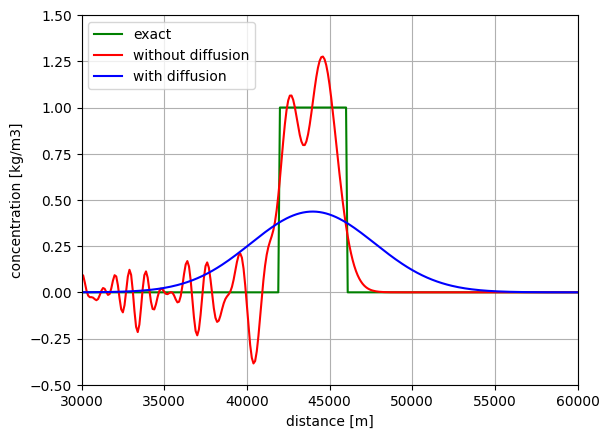

In [8]:
# parameters for Task 3.1

v = 0.35
K = 55.

plt.plot(x,c1,'g',label='exact')

# compute the end time and time step
Tend = np.ceil(distance/v)
sigma = 0.75
dt = np.floor(sigma * dx / v)
N = int(Tend/dt)

# solve the advection-diffusion equation using the Crank-Nicolson scheme
# without diffusion
c = advdiff(v,0,c0,lenD,dt,Tend,'central','theta',0.5)
plt.plot(x,c[N,:],'r',label='without diffusion')

# with diffusion
c = advdiff(v,K,c0,lenD,dt,Tend,'central','theta',0.5)
plt.plot(x,c[N,:],'b',label='with diffusion')
print('mesh Peclet number = ',v*dx/K)

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.5,1.5]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
<b>Solution 3.1</b>

The case without diffusion ($K=0$) represents a propagated substance along the river as shown by the green curve.
Its shape is fixed throughout the propagation. However, the Crank-Nicolson scheme is not able to conserve this block-shaped profile.
The associated numerical solution contains wiggles as the scheme does not have numerical diffusion.

The case with diffusion ($K = 55$ m<sup>2</sup>/s) represents a propagated substance while it spreads in the river as time proceeds.
So its shape becomes more smooth during its journey through the river and also takes the shape of a Gaussian bell curve.

The Crank-Nicolson scheme seems to be able to reproduce this curve (see blue curve) because the [mesh P&eacute;clet](https://mude.citg.tudelft.nl/book/2025/numerical_methods_for_PDEs/advection_diffusion_eq.html#stationary-advection-diffusion-equation) number is less than 2.
Also note that this scheme has no numerical diffusion so the smoothing is caused solely by physical diffusion.

</p>
</div>

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.2</b>

Repeat the last simulation (with diffusion $K = 55$ m<sup>2</sup>/s), but now with the forward Euler scheme.
Hence, the resulting scheme is the FTCS scheme.

What happens? And why does this happen?

</p>
</div>

stability condition: K*dt/dx^2 =  1.177


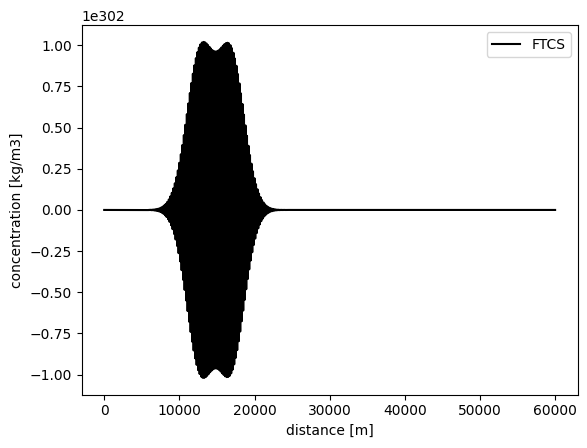

In [9]:
# FTCS
cf = advdiff(v,K,c0,lenD,dt,Tend,'central','theta',0.0)
plt.plot(x,cf[N,:],'k',label='FTCS')
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper right")
print('stability condition: K*dt/dx^2 = ',K*dt/(dx*dx))

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.3</b>

Derive the stability limit for the FTCS scheme, modify accordingly the time step and do the simulation again.

Conclusion?

Write down your explanation and conclusions in your report.

</p>
</div>

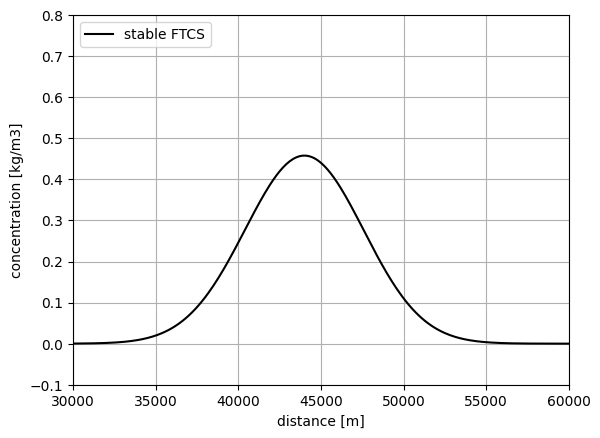

In [10]:
# time step based on stability of explicit Euler
dt2 = np.floor(0.5 * dx*dx / K)
ce = advdiff(v,K,c0,lenD,dt2,Tend,'central','theta',0.)
N2 = int(Tend/dt2)
plt.plot(x,ce[N2,:],'k',label='stable FTCS')

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.1,0.8]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.4</b>

Now repeat the last simulation with the modified time step, but this time with the FTBS scheme instead of FTCS.

What do you observe? Provide an explanation.

</p>
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>

$\text{Hint:}$

Take into account the numerical diffusion.

</p>
</div>

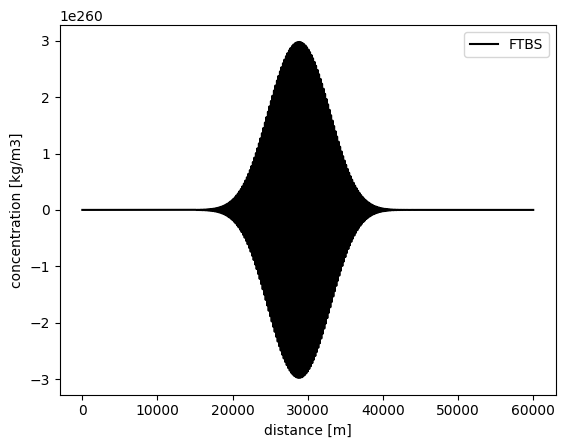

In [11]:
# FTBS scheme
cb = advdiff(v,K,c0,lenD,dt2,Tend,'upwind','theta',0.)
plt.plot(x,cb[N2,:],'k',label='FTBS')
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper right")

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.5</b>

We will run the last simulation again, but with a smaller time step.

What is the maximum time step at which FTBS becomes stable?
Derive this maximum time step theoretically.

</p>
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>

$\text{Hint:}$

Consult this week's WS - part 3.

</p>
</div>

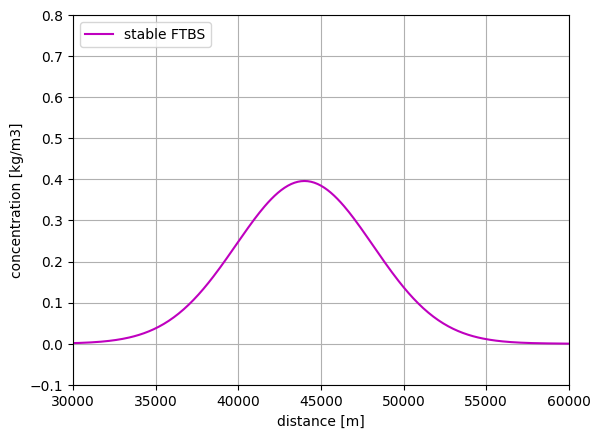

In [12]:
# time step based on stability of FTBS
# for this, add artificial diffusion
Ka = 0.5 * v * dx
Ku = K + Ka
dt3 = np.floor(0.5 * dx*dx / Ku)
cu = advdiff(v,K,c0,lenD,dt3,Tend,'upwind','theta',0.)
N3 = int(Tend/dt3)
plt.plot(x,cu[N3,:],'m',label='stable FTBS')

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.1,0.8]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>
<b>Task 3.6</b>

Hopefully, you have now found three different stable numerical solutions of the advection-diffusion equation with
$v= 0.35$ m/s and $K = 55$ m<sup>2</sup>/s, namely,
- the one obtained from Crank-Nicolson with central differences (Task 3.1),
- the one obtained from stable FTCS scheme (Task 3.3), and
- the one obtained from stable FTBS scheme (Task 3.5).

Plot these solutions in a graph. Mark clearly the curves.

Answer the following questions in your report.

1. Which of the schemes is the most accurate one? Why?
2. Which of the numerical solutions has the largest maximum? Why?

</p>
</div>

<div style="background-color:#facb8e; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>

$\text{Hint:}$

For the last question, please consult Part 3 of WS 2.1.

</p>
</div>

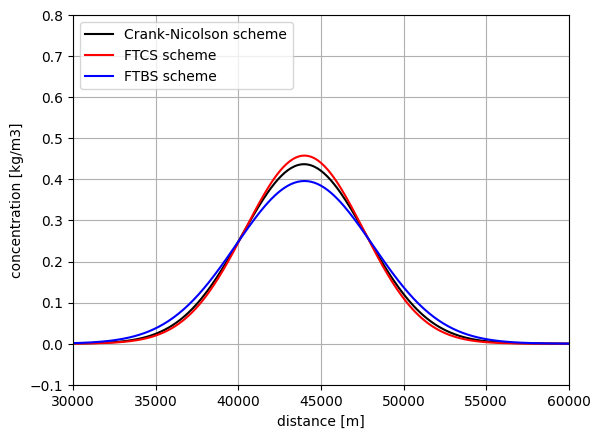

In [13]:
# plot the three solutions
plt.plot(x,c[N,:],'k',label='Crank-Nicolson scheme')
plt.plot(x,ce[N2,:],'r',label='FTCS scheme')
plt.plot(x,cu[N3,:],'b',label='FTBS scheme')

# finalize the plot
plt.axis(np.array([lenD/2,lenD,-0.1,0.8]))
plt.xlabel('distance [m]')
plt.ylabel('concentration [kg/m3]')
plt.legend(loc = "upper left")
plt.grid()

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
<b>Solution 3.6</b>

1. The Crank-Nicolson scheme because it is second order accurate both in time and space and does not contain numerical diffusion.
2. The FTCS scheme because the forward Euler scheme produces *negative* amount of diffusion which implies a larger maximum.

</p>
</div>

> By Marcel Zijlema, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).